In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import json

Successfully loaded 940 total rows of erasure data.


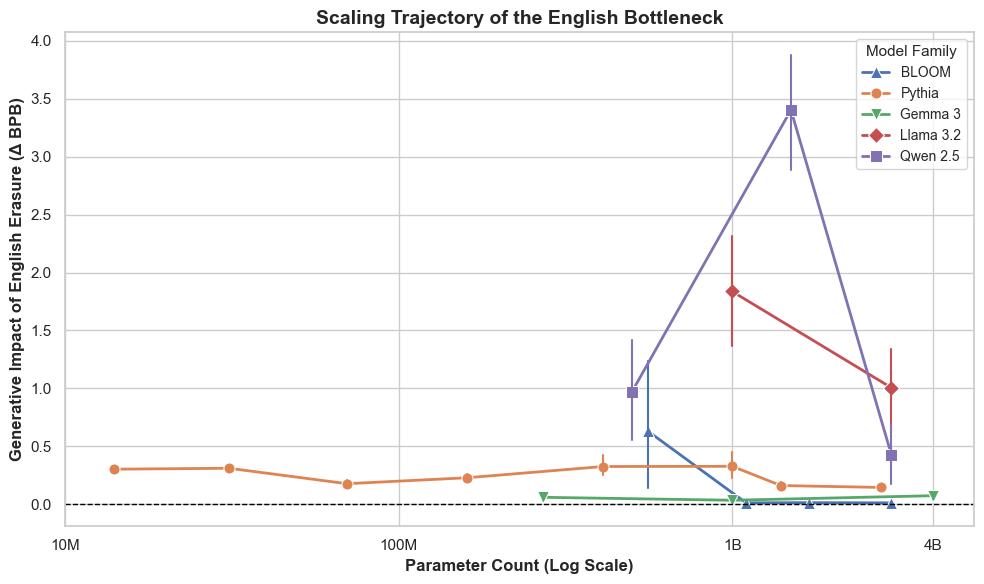

Chart successfully saved to: analysis_output/Fig1_Scaling_Trajectory.png

[SUCCESS] Aggregated data saved to: analysis_output/scaling_trajectory_data.json

Preview of extracted coordinates:
| family    | model                   |   Parameters_M |   Mean_BPB_Delta |   Standard_Error |
|:----------|:------------------------|---------------:|-----------------:|-----------------:|
| BLOOM     | bigscience_bloom-560m   |            560 |        0.628308  |       0.263343   |
| BLOOM     | bigscience_bloom-1b1    |           1100 |        0.0116124 |       0.00316158 |
| BLOOM     | bigscience_bloom-1b7    |           1700 |        0.0127471 |       0.00487862 |
| BLOOM     | bigscience_bloom-3b     |           3000 |        0.0110652 |       0.00241529 |
| Gemma 3   | google_gemma-3-270m-it  |            270 |        0.0591885 |       0.0107689  |
| Gemma 3   | google_gemma-3-1b-it    |           1000 |        0.0336059 |       0.00919977 |
| Gemma 3   | google_gemma-3-4b-it    |           

In [2]:
# ==========================================
# CONFIGURATION & LOAD
# ==========================================
RESULTS_DIR = "data/"
OUTPUT_DIR = "analysis_output/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

param_map = {
    # Pythia
    "EleutherAI_pythia-14m": 14, "EleutherAI_pythia-31m": 31, "EleutherAI_pythia-70m": 70,
    "EleutherAI_pythia-160m": 160, "EleutherAI_pythia-410m": 410, "EleutherAI_pythia-1b": 1000,
    "EleutherAI_pythia-1.4b": 1400, "EleutherAI_pythia-2.8b": 2800,
    # Qwen
    "Qwen_Qwen2.5-0.5B": 500, "Qwen_Qwen2.5-1.5B": 1500, "Qwen_Qwen2.5-3B": 3000,
    # Llama
    "meta-llama_Llama-3.2-1B": 1000, "meta-llama_Llama-3.2-3B": 3000,
    # BLOOM
    "bigscience_bloom-560m": 560, "bigscience_bloom-1b1": 1100,
    "bigscience_bloom-1b7": 1700, "bigscience_bloom-3b": 3000,
    # Gemma
    "google_gemma-3-270m-it": 270, "google_gemma-3-1b-it": 1000, "google_gemma-3-4b-it": 4000
}

def get_family(model_name):
    lower = model_name.lower()
    if "pythia" in lower: return "Pythia"
    if "qwen" in lower: return "Qwen 2.5"
    if "bloom" in lower: return "BLOOM"
    if "gemma" in lower: return "Gemma 3"
    if "llama" in lower: return "Llama 3.2"
    return "Other"

def load_and_prep_scale_data(pattern, metric_col):
    files = glob.glob(os.path.join(RESULTS_DIR, pattern))
    if not files: raise FileNotFoundError(f"No CSVs found for {pattern}")
    
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        if 'model' not in df.columns:
            base_name = os.path.basename(f)
            clean_name = base_name.replace("validation_", "").replace("erasure_", "").replace(".csv", "")
            clean_name = clean_name.split("_seed")[0]
            df['model'] = clean_name
        dfs.append(df)
    
    df = pd.concat(dfs, ignore_index=True)
    df['model'] = df['model'].str.replace("/", "_")
    df['family'] = df['model'].apply(get_family)
    
    # Isolate English erasure and map parameters
    df_eng = df[df['erased_concept'] == 'eng'].copy()
    df_eng['Parameters_M'] = df_eng['model'].map(param_map)
    return df_eng.dropna(subset=['Parameters_M'])

df_scale = load_and_prep_scale_data("erasure_*.csv", "bpb_delta")

print(f"Successfully loaded {len(df_scale)} total rows of erasure data.")

# ==========================================
# PLOTTING HELPERS
# ==========================================
sns.set_theme(style="whitegrid")
markers = {"Pythia": "o", "Qwen 2.5": "s", "Llama 3.2": "D", "BLOOM": "^", "Gemma 3": "v"}

def plot_trajectory(data, y_col, ylabel, title, out_filename):
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=data, x='Parameters_M', y=y_col, hue='family', style='family',
        markers=markers, dashes=False, err_style="bars", linewidth=2, markersize=8, palette="deep"
    )
    plt.xscale('log')
    plt.xlabel("Parameter Count (Log Scale)", fontsize=12, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    tick_locs = [10, 100, 1000, 4000]
    tick_labels = ['10M', '100M', '1B', '4B']
    plt.xticks(tick_locs, tick_labels)
    
    plt.legend(title="Model Family", fontsize=10, title_fontsize=11)
    plt.tight_layout()
    
    out_path = os.path.join(OUTPUT_DIR, out_filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Chart successfully saved to: {out_path}")

# Generate Plots
plot_trajectory(df_scale, 'bpb_delta', "Generative Impact of English Erasure (Δ BPB)", 
                "Scaling Trajectory of the English Bottleneck", "Fig1_Scaling_Trajectory.png")

# ==========================================
# AGGREGATE & EXPORT TO JSON
# ==========================================
def export_summary(df, y_col, out_name, json_key):
    summary = df.groupby(['family', 'model', 'Parameters_M'])[y_col].agg(
        Mean='mean', Standard_Error='sem'
    ).reset_index()
    

    summary.rename(columns={'Mean': 'Mean_BPB_Delta'}, inplace=True)
        
    summary = summary.sort_values(by=['family', 'Parameters_M'])
    
    out_path = os.path.join(OUTPUT_DIR, out_name)
    with open(out_path, "w") as f:
        json.dump({json_key: summary.to_dict(orient="records")}, f, indent=4)
        
    print(f"\n[SUCCESS] Aggregated data saved to: {out_path}")
    print("\nPreview of extracted coordinates:")
    print(summary.head(10).to_markdown(index=False))

export_summary(df_scale, 'bpb_delta', "scaling_trajectory_data.json", "scaling_generative_impact")